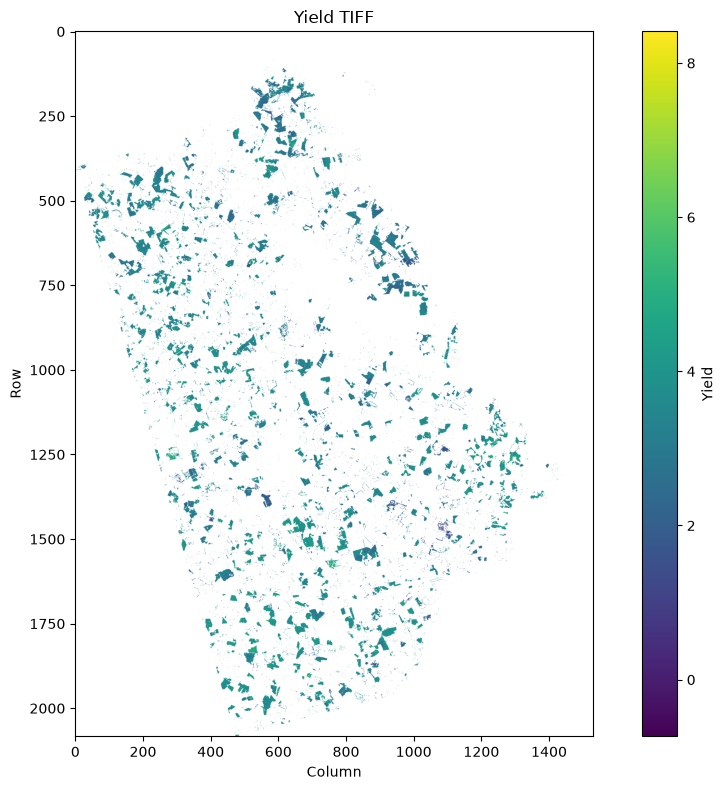

Available Layers:
Band 1: NDVI_mean
Band 2: EVI_mean
Band 3: GCVI_mean
Band 4: NDWI_mean
Band 5: NDVI_obsCount
Band 6: EVI_obsCount
Band 7: GCVI_obsCount
Band 8: NDWI_obsCount
Band 9: min_index_obsCount
Band 10: crop_mask
Band 11: valid_vi_mask


In [4]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Give your TIFF file path here
tif_path = r'/Users/samarranjit/Library/CloudStorage/OneDrive-TexasStateUniversity/ChoLab/USDA Crop yield Stability Study/EO based yield prediction/data_preparation/outputs/county_vi_summary/pixel_vi_tifs/soybeans_DE_2014_10001_Kent_vi_pixels_nasa_cmr_hls.tif'

# Read the TIFF file
with rasterio.open(tif_path) as src:
    data = src.read(3)          # read first band
    nodata = src.nodata

# Convert NoData values to NaN
data = data.astype(float)

if nodata is not None:
    data[data == nodata] = np.nan

# Optional: remove zero values if zero means missing data
data[data == 0] = np.nan

# Plot the TIFF
plt.figure(figsize=(10, 8))
plt.imshow(data, cmap="viridis")
plt.colorbar(label="Yield")
plt.title("Yield TIFF")
plt.xlabel("Column")
plt.ylabel("Row")
plt.tight_layout()
plt.show()


with rasterio.open(tif_path) as src:
    # Get the names of all layers
    layer_names = src.descriptions
    
    # Print them out with their corresponding band index
    print("Available Layers:")
    for i, name in enumerate(layer_names, start=1):
        print(f"Band {i}: {name}")

===== All Layers in GPKG =====
0: selected_states_counties_2023

===== Layers where STATEFP == 18 =====

Layer: selected_states_counties_2023
Rows: 1382
Columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
FOUND: 92 matching features

===== Matching Layers =====
selected_states_counties_2023

No layer selected. Plotting first matching layer: selected_states_counties_2023

===== Selected Layer Details =====
Layer: selected_states_counties_2023
Matching rows: 92
CRS: EPSG:5070
Geometry types: <StringArray>
['MultiPolygon']
Length: 1, dtype: str
   STATEFP COUNTYFP  COUNTYNS  GEOID         GEOIDFQ     NAME        NAMELSAD  \
21      18      073  00450494  18073  0500000US18073   Jasper   Jasper County   
22      18      151  00450390  18151  0500000US18151  Steuben  Steuben County   
43      18      115  00450378  18115  0500000US181

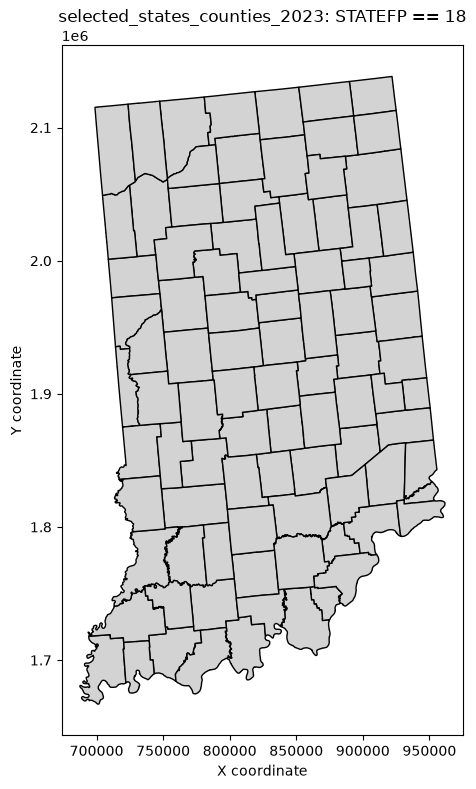

In [5]:
# ============================================================
# Read GPKG, find layers where COUNTYFP == 18, and plot them
# ============================================================

import geopandas as gpd
import fiona
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 1. Give your GPKG file path here
# ------------------------------------------------------------
gpkg_path = r"/Users/samarranjit/Library/CloudStorage/OneDrive-TexasStateUniversity/ChoLab/USDA Crop yield Stability Study/EO based yield prediction/data_preparation/data/counties/selected_states_counties_2023.gpkg"

# Column and value to filter
filter_column = "STATEFP"
filter_value = 18

# If you want to manually plot one matching layer, put its name here
# Otherwise, it will plot the first matching layer
layer_to_plot = None


# ------------------------------------------------------------
# 2. Check file exists
# ------------------------------------------------------------
gpkg_path = Path(gpkg_path)

if not gpkg_path.exists():
    raise FileNotFoundError(f"File not found: {gpkg_path}")


# ------------------------------------------------------------
# 3. List all layers
# ------------------------------------------------------------
layers = fiona.listlayers(gpkg_path)

print("===== All Layers in GPKG =====")
for i, layer in enumerate(layers):
    print(f"{i}: {layer}")
print()


# ------------------------------------------------------------
# 4. Check which layers have COUNTYFP == 18
# ------------------------------------------------------------
matching_layers = []

print(f"===== Layers where {filter_column} == {filter_value} =====")

for layer in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer)

    print(f"\nLayer: {layer}")
    print(f"Rows: {len(gdf)}")
    print(f"Columns: {list(gdf.columns)}")

    if filter_column not in gdf.columns:
        print(f"'{filter_column}' column not found.")
        continue

    # Convert COUNTYFP to number, so values like "18" or "018" still work
    countyfp_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")

    matches = gdf[countyfp_numeric == filter_value]

    if len(matches) > 0:
        print(f"FOUND: {len(matches)} matching features")
        matching_layers.append(layer)
    else:
        print("No matching features.")

print("\n===== Matching Layers =====")
if matching_layers:
    for layer in matching_layers:
        print(layer)
else:
    print("No layers found with COUNTYFP == 18.")


# ------------------------------------------------------------
# 5. Choose layer to plot
# ------------------------------------------------------------
if not matching_layers:
    raise ValueError(f"No layers found with {filter_column} == {filter_value}")

if layer_to_plot is None:
    layer_to_plot = matching_layers[0]
    print(f"\nNo layer selected. Plotting first matching layer: {layer_to_plot}")


# ------------------------------------------------------------
# 6. Read and filter selected layer
# ------------------------------------------------------------
gdf = gpd.read_file(gpkg_path, layer=layer_to_plot)

countyfp_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")
gdf_match = gdf[countyfp_numeric == filter_value]

print("\n===== Selected Layer Details =====")
print(f"Layer: {layer_to_plot}")
print(f"Matching rows: {len(gdf_match)}")
print(f"CRS: {gdf_match.crs}")
print(f"Geometry types: {gdf_match.geometry.geom_type.unique()}")
print(gdf_match.head())


# ------------------------------------------------------------
# 7. Plot only features where COUNTYFP == 18
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

gdf_match.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightgray",
    linewidth=1
)

ax.set_title(f"{layer_to_plot}: {filter_column} == {filter_value}")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

===== TIFF DETAILS =====
File: nass_soybeans_yield_DE_2014_nearest_30m_soybeans_only.tif
Width: 3261
Height: 5133
CRS: EPSG:5070
NoData: -9999.0
Bounds: BoundingBox(left=1704030.0, bottom=1901190.0, right=1801860.0, top=2055180.0)
Number of bands: 1

===== TIFF DATA SUMMARY =====
Min: 46.200685408921935
Max: 51.8007703589684
Mean: 47.63161818383157
Valid pixels: 475075

===== GPKG LAYERS =====
0: selected_states_counties_2023

===== Layer: selected_states_counties_2023 =====
Rows: 1382
CRS: EPSG:5070
Columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
Geometry types: <StringArray>
['MultiPolygon']
Length: 1, dtype: str
Rows where STATEFP == 10: 3

Using layer: selected_states_counties_2023

===== SELECTED GPKG DATA =====
Layer: selected_states_counties_2023
Matching rows: 3
CRS: EPSG:5070
     STATEFP COUNTYFP  COUNTYNS  GEOID   

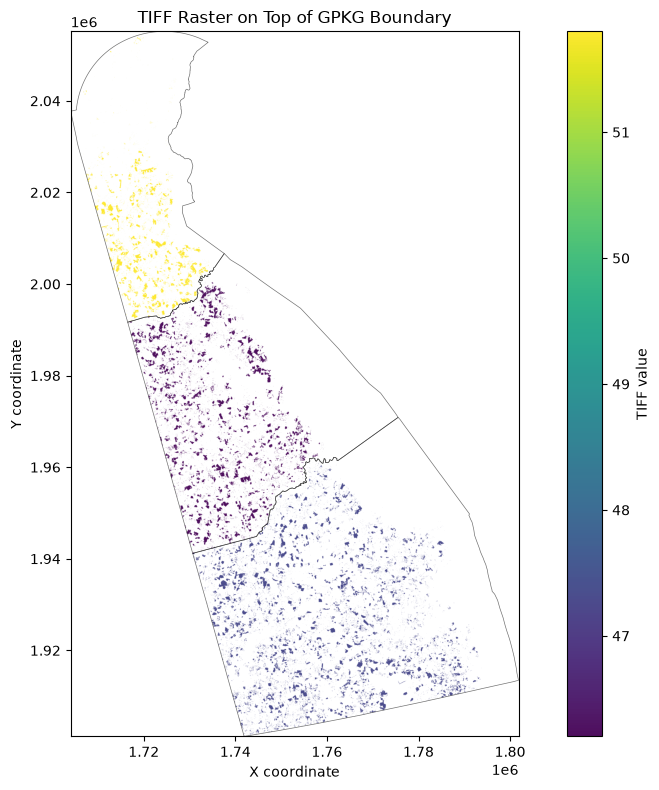

In [5]:
# ============================================================
# Read TIFF + GPKG and plot together
# GPKG plotted faintly, TIFF plotted clearly on top
# ============================================================

import rasterio
from rasterio.plot import plotting_extent
import geopandas as gpd
import fiona
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------
tif_path = r"/Users/samarranjit/Library/CloudStorage/OneDrive-TexasStateUniversity/ChoLab/USDA Crop yield Stability Study/EO based yield prediction/data_preparation/data/yield_labels/2014/nass_soybeans_yield_DE_2014_nearest_30m_soybeans_only.tif"

gpkg_path = r"/Users/samarranjit/Library/CloudStorage/OneDrive-TexasStateUniversity/ChoLab/USDA Crop yield Stability Study/EO based yield prediction/data_preparation/data/counties/selected_states_counties_2023.gpkg"


# ------------------------------------------------------------
# 2. GPKG filter settings
# ------------------------------------------------------------
filter_column = "STATEFP"
filter_value = 10

# Keep None to automatically use the first layer that matches
layer_to_plot = None


# ------------------------------------------------------------
# 3. Read TIFF
# ------------------------------------------------------------
with rasterio.open(tif_path) as src:
    data = src.read(1).astype(float)
    nodata = src.nodata
    raster_crs = src.crs
    raster_extent = plotting_extent(src)

    print("===== TIFF DETAILS =====")
    print(f"File: {Path(tif_path).name}")
    print(f"Width: {src.width}")
    print(f"Height: {src.height}")
    print(f"CRS: {src.crs}")
    print(f"NoData: {src.nodata}")
    print(f"Bounds: {src.bounds}")
    print(f"Number of bands: {src.count}")
    print()

# Clean TIFF data
if nodata is not None:
    data[data == nodata] = np.nan

# Remove zeros if they mean no data
data[data == 0] = np.nan

data = data / 67.25

print("===== TIFF DATA SUMMARY =====")
print(f"Min: {np.nanmin(data)}")
print(f"Max: {np.nanmax(data)}")
print(f"Mean: {np.nanmean(data)}")
print(f"Valid pixels: {np.count_nonzero(~np.isnan(data))}")
print()


# ------------------------------------------------------------
# 4. Read GPKG layers and print details
# ------------------------------------------------------------
gpkg_path = Path(gpkg_path)

if not gpkg_path.exists():
    raise FileNotFoundError(f"GPKG file not found: {gpkg_path}")

layers = fiona.listlayers(gpkg_path)

print("===== GPKG LAYERS =====")
for i, layer in enumerate(layers):
    print(f"{i}: {layer}")
print()


matching_layers = []

for layer in layers:
    gdf = gpd.read_file(gpkg_path, layer=layer)

    print(f"===== Layer: {layer} =====")
    print(f"Rows: {len(gdf)}")
    print(f"CRS: {gdf.crs}")
    print(f"Columns: {list(gdf.columns)}")
    print(f"Geometry types: {gdf.geometry.geom_type.unique()}")

    if filter_column in gdf.columns:
        values_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")
        matches = gdf[values_numeric == filter_value]

        print(f"Rows where {filter_column} == {filter_value}: {len(matches)}")

        if len(matches) > 0:
            matching_layers.append(layer)
    else:
        print(f"Column {filter_column} not found.")

    print()


# ------------------------------------------------------------
# 5. Choose matching layer
# ------------------------------------------------------------
if not matching_layers:
    raise ValueError(f"No layer found with {filter_column} == {filter_value}")

if layer_to_plot is None:
    layer_to_plot = matching_layers[0]

print(f"Using layer: {layer_to_plot}")
print()


# ------------------------------------------------------------
# 6. Read selected GPKG layer and filter it
# ------------------------------------------------------------
gdf = gpd.read_file(gpkg_path, layer=layer_to_plot)

values_numeric = pd.to_numeric(gdf[filter_column], errors="coerce")
gdf_match = gdf[values_numeric == filter_value]

print("===== SELECTED GPKG DATA =====")
print(f"Layer: {layer_to_plot}")
print(f"Matching rows: {len(gdf_match)}")
print(f"CRS: {gdf_match.crs}")
print(gdf_match.head())
print()


# ------------------------------------------------------------
# 7. Reproject GPKG to match TIFF CRS
# ------------------------------------------------------------
if gdf_match.crs != raster_crs:
    gdf_match = gdf_match.to_crs(raster_crs)
    print("Reprojected GPKG to match TIFF CRS.")
    print(f"New GPKG CRS: {gdf_match.crs}")
    print()


# ------------------------------------------------------------
# 8. Plot GPKG first, then TIFF on top
# ------------------------------------------------------------
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)   # makes NaN pixels transparent

fig, ax = plt.subplots(figsize=(10, 8))



# Plot TIFF on top
img = ax.imshow(
    data,
    cmap=cmap,
    extent=raster_extent,
    alpha=0.95
)

# Plot GPKG underneath with low opacity
gdf_match.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.55
)

plt.colorbar(img, ax=ax, label="TIFF value")

ax.set_title("TIFF Raster on Top of GPKG Boundary")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()